📘 Dataset Description

The Smart Irrigation Water Requirement Prediction Dataset aims to optimize water usage in agriculture by predicting the amount of irrigation required under varying environmental conditions.
 Efficient water management is critical for sustainable farming, especially in water-scarce regions.

The dataset includes crop type, soil type, temperature, rainfall, and evapotranspiration parameters, enabling accurate estimation of irrigation needs using machine learning models.
 It supports regression tasks and smart irrigation system development.

🔍 Use Cases

- Smart irrigation systems
- Water resource optimization
- Climate-aware agriculture solutions
- Machine learning regression projects

In [1]:
import os

import joblib
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
from optuna import create_study, samplers, pruners, exceptions, visualization
from optuna.study import StudyDirection
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit, KFold, StratifiedKFold, train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, KMeansSMOTE, RandomOverSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight

In [2]:
load_dotenv()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
output_path = 'data/irrigation-water'
if os.path.exists(output_path):
    print(f"Directory '{output_path}' already exists. Skipping download.")
    path = output_path
else:
    # Download latest version
    path = kagglehub.competition_download('playground-series-s6e4', output_dir=output_path)

    print("Path to competition files:", path)

Directory 'data/irrigation-water' already exists. Skipping download.


In [4]:
test_df = pd.read_csv(os.path.join(path, 'test.csv'))
train_df = pd.read_csv(os.path.join(path, 'train.csv'))

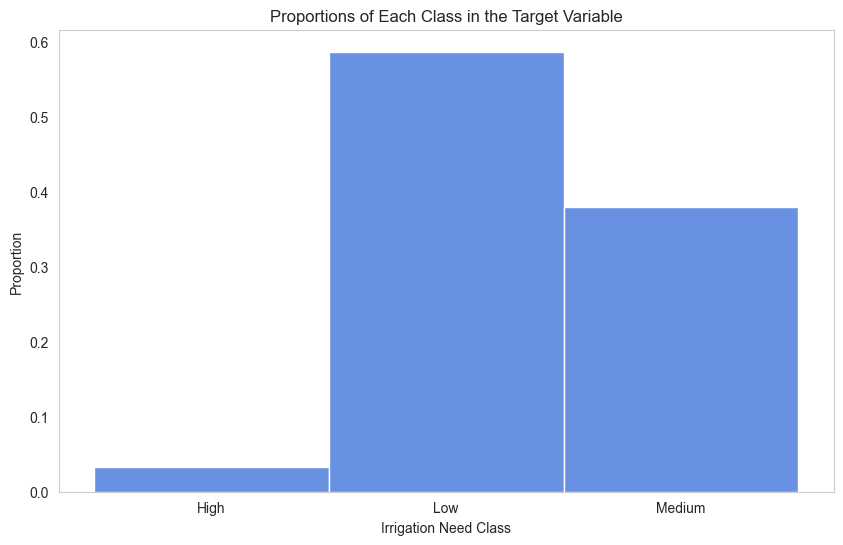

In [5]:
proportions = (train_df['Irrigation_Need'].value_counts() / len(train_df)).sort_index()

sns.histplot(x=proportions.index, weights=proportions.values, bins=len(proportions), kde=False)
plt.title('Proportions of Each Class in the Target Variable')
plt.xlabel('Irrigation Need Class')
plt.ylabel('Proportion')
plt.xticks(proportions.index)
plt.grid()
plt.show()

In [ ]:
train_df.head(5)

In [ ]:
train_df.describe()

In [5]:
string_columns = train_df.select_dtypes(include=[str]).columns
print("String columns in the dataset:", string_columns)

String columns in the dataset: Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='str')


In [ ]:
for col in string_columns:
    print(f"Unique values in column '{col}': {train_df[col].unique()}")

In [6]:
# Separate features and target variable
X = train_df.drop('Irrigation_Need', axis=1)
y = train_df['Irrigation_Need']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
X_train.shape, X_val.shape # check quantity of data after split

((598500, 20), (31500, 20))

In [7]:
one_hot_columns = ['Crop_Type', 'Soil_Type', 'Season', 'Region', 'Water_Source', 'Irrigation_Type']
label_columns = ['Crop_Growth_Stage', 'Mulching_Used']
numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [8]:
target_encoder = LabelEncoder() # we need decode after prediction
train_df['Irrigation_Need'] = target_encoder.fit_transform(train_df['Irrigation_Need'])

## Problem of dataset
1. Dataset is imbalanced (0 - 3%, 1- 59%, 2 - 38%). We can use class weights in RandomForestClassifier or try to oversample minority classes with SMOTE.
2. After One-Hot Encoding, we will have 30+ features, which can lead to overfitting. We can try dimensionality reduction techniques like PCA or feature selection based on feature importance.
3. Some features may have low importance for prediction. We can analyze feature importance from the Random Forest model and consider removing less important features to simplify the model and reduce overfitting risk.
4. Seems dataset is more than 1000k rows, so HPO can be time-consuming. We can try to decrease of dataset size with stratified sampling or use a smaller subset for HPO to speed up the process.

# Strategy
1. Create a function make_pipeline with arguments
2. Use this function to create a pipeline and tune it with Optuna
3. Evaluate the model with classification report, confusion matrix, accuracy and balanced accuracy as separate function
4. at the end show visualization of optuna optimization process and feature importance

In [9]:
# Create pipelines for one-hot encoding and label encoding
column_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), one_hot_columns),
        ('label', OrdinalEncoder(), label_columns),
    ],
    remainder='passthrough'
)

In [ ]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', rfc)
])

In [ ]:
model_path = 'irrigation_rf_pipeline.joblib'
if os.path.exists(model_path):
    print(f"Model file '{model_path}' already exists. Loading model.")
    pipeline = joblib.load(model_path)
else:
    fitted_model = pipeline.fit(X_train, y_train) # 3m41s without PCA
    joblib.dump(fitted_model, model_path)
    print(f"Model saved to '{model_path}'.")

In [ ]:
feature_importance = pipeline.named_steps['classifier'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

In [ ]:
report = classification_report(y_val, pipeline.predict(X_val))
print(report)

In [ ]:
conf_matrix = confusion_matrix(y_val, pipeline.predict(X_val))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
accuracy = accuracy_score(y_val, pipeline.predict(X_val))
print(f'Validation Accuracy: {accuracy:.4f}')

In [ ]:
balanced_accuracy = balanced_accuracy_score(y_val, pipeline.predict(X_val))
print(f'Validation Balanced Accuracy: {balanced_accuracy:.4f}')

# Tune model with Optuna

In [10]:
class EarlyStoppingCallback:

  def __init__(self, patience: int, min_delta: float = 0.0):
      self.patience = patience
      self.min_delta = min_delta
      self.counter = 0
      self.best_value = None

  def __call__(self, study, trial):
      # initialize
      if self.best_value is None:
          self.best_value = study.best_value
          return

      # check improvement by study direction
      if study.direction == StudyDirection.MINIMIZE:
          improved = study.best_value < self.best_value - self.min_delta
      else:  # MAXIMIZE
          improved = study.best_value > self.best_value + self.min_delta

      if improved:
          self.best_value = study.best_value
          self.counter = 0
      else:
          self.counter += 1

      if self.counter >= self.patience:
          study.stop()
          print(f'Early stopping triggered after {self.counter} trials with no improvement.')

In [11]:
classes = np.unique(y)
weight = compute_class_weight(class_weight="balanced", classes=classes, y=y) # calculate class weights for imbalanced dataset
class_weight = dict(zip(classes, weight))

In [ ]:
def objective_warm_start(trial):
    # hyperparams
    total_n_estimators = trial.suggest_int('n_estimators', 25, 200)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)

    # subsample if needed
    n_samples = 10000
    if n_samples < len(X_train):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=42)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_small = X_train.iloc[train_idx]
        y_small = y_train.iloc[train_idx]
    else:
        X_small, y_small = X_train, y_train

    # create classifier with warm_start=True
    rfc = RandomForestClassifier(
        n_estimators=1,  # start small
        warm_start=True,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', column_transformer),
        ('classifier', rfc)
    ])

    # progressively add trees and report intermediate metrics
    n_steps = 5
    estimators_per_step = max(1, total_n_estimators // n_steps)
    current_estimators = 0
    for step in range(n_steps):
        current_estimators += estimators_per_step
        rfc.n_estimators = min(current_estimators, total_n_estimators)
        pipeline.fit(X_small, y_small)  # this will add trees when warm_start=True
        y_pred = pipeline.predict(X_val)
        metric = balanced_accuracy_score(y_val, y_pred)
        trial.report(metric, step)
        if trial.should_prune():
            raise exceptions.TrialPruned()

        # stop earlier if we've reached target number of estimators
        if rfc.n_estimators >= total_n_estimators:
            break

    return metric

In [12]:
pruner = pruners.PatientPruner(pruners.SuccessiveHalvingPruner(), patience=10)
es_cb = EarlyStoppingCallback(patience=10, min_delta=0.001)


C:\Users\username\AppData\Local\Temp\ipykernel_1256\2597114814.py:1: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner = pruners.PatientPruner(pruners.SuccessiveHalvingPruner(), patience=10)


In [ ]:

study = create_study(
                     direction='maximize',
                     sampler=samplers.TPESampler(seed=42),
                     storage='sqlite:///optuna_irrigation.db',
                     pruner=pruner)

study.optimize(objective_warm_start,
               n_trials=100,
               n_jobs=-1,
               show_progress_bar=True,
               callbacks=[es_cb])

In [ ]:
visualization.plot_parallel_coordinate(study)

In [ ]:
study.best_params

In [ ]:
best_params = {'n_estimators': 198,  'max_depth': 16,  'min_samples_split': 3,  'min_samples_leaf': 4}
# create classifier with warm_start=True
rfc = RandomForestClassifier(
    warm_start=True,
    **study.best_params,
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', rfc)
])

pipeline.fit(X_train, y_train)

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

score = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1
)

ball_acc = np.sqrt(-score.mean())
ball_acc

In [ ]:
score

In [ ]:
y_pred = pipeline.predict(X_val)
metric = balanced_accuracy_score(y_val, y_pred)
metric

In [ ]:
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Optuna Objective with RFE

In [13]:
# subsample if needed
n_samples = 10000
if n_samples < len(X_train):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=42)
    train_idx, _ = next(sss.split(X_train, y_train))
    X_small = X_train.iloc[train_idx]
    y_small = y_train.iloc[train_idx]
else:
    X_small, y_small = X_train, y_train

In [ ]:
X_tansformed = column_transformer.fit_transform(X_small)

In [ ]:
max_num_features = X_tansformed.shape[1]

In [14]:
def objective(trial):

    rf_params = {
        "n_estimators": trial.suggest_int("n_estimators", 20, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }

    #  ADASYN, KMeansSMOTE, RandomOverSampler
    balancing_method = trial.suggest_categorical("balancing", ("smote", "adasyn", "random_sampler"))

    match balancing_method:

        case "smote":
            suggested_balancing_method = SMOTE(
                random_state=42,
                k_neighbors=3
            )

        case "adasyn":
            suggested_balancing_method = ADASYN(
                random_state=42,
                n_neighbors=3
            )

        case "random_sampler":
            suggested_balancing_method = RandomOverSampler(
                random_state=42
            )

        case _:
            suggested_balancing_method = None

    # Feature selector estimator
    rfe_estimator = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    n_features = trial.suggest_int(
        "n_features_to_select",
        4,
        # 10 # remove this for case deep tuning, but this make not sense
        max_num_features
    )

    selector = RFE(
        estimator=rfe_estimator,
        n_features_to_select=n_features,
        step=1
    )

    classifier = RandomForestClassifier(
        **rf_params
    )

    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", column_transformer),

            ("balancing", suggested_balancing_method),

            ("feature_selection", selector),

            ("classifier", classifier)
        ]
    )

    cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

    scores = cross_val_score(
        pipeline,
        X_val,
        y_val,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )
    metric = scores.mean()

    # pipeline.fit(X_small, y_small)
    #
    # y_pred = pipeline.predict(X_val)
    # metric = balanced_accuracy_score(y_val, y_pred)

    if trial.should_prune():
        raise exceptions.TrialPruned()

    return metric

In [15]:
pruner = pruners.PatientPruner(pruners.SuccessiveHalvingPruner(), patience=10)
es_cb = EarlyStoppingCallback(patience=10, min_delta=0.001)

study = create_study(
                     direction='maximize',
                     sampler=samplers.TPESampler(seed=42),
                     storage='sqlite:///optuna_irrigation.db',
                     pruner=pruner)

study.optimize(objective,
               n_trials=100,
               n_jobs=-1,
               show_progress_bar=True,
               callbacks=[es_cb])

C:\Users\username\AppData\Local\Temp\ipykernel_1256\3731639624.py:1: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner = pruners.PatientPruner(pruners.SuccessiveHalvingPruner(), patience=10)
[I 2026-05-24 14:24:53,189] A new study created in RDB with name: no-name-f4e832cc-3499-46ae-adaa-9baa7764e9f4


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-24 14:29:19,648] Trial 4 finished with value: 0.9561059374229801 and parameters: {'n_estimators': 90, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'balancing': 'random_sampler', 'n_features_to_select': 9}. Best is trial 4 with value: 0.9561059374229801.
[I 2026-05-24 14:29:43,805] Trial 0 finished with value: 0.9560383576824982 and parameters: {'n_estimators': 132, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'balancing': 'random_sampler', 'n_features_to_select': 8}. Best is trial 4 with value: 0.9561059374229801.
[I 2026-05-24 14:30:48,833] Trial 7 finished with value: 0.9397423255454654 and parameters: {'n_estimators': 148, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'log2', 'balancing': 'smote', 'n_features_to_select': 9}. Best is trial 4 with value: 0.9561059374229801.
[I 2026-05-24 14:31:15,141] Trial 3 finished with value: 0.9185056230268978 and par

In [16]:
study.best_params

{'n_estimators': 90,
 'max_depth': 11,
 'min_samples_split': 15,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'balancing': 'random_sampler',
 'n_features_to_select': 9}

In [18]:
visualization.plot_parallel_coordinate(study)

In [19]:
best_params = study.best_params.copy()

n_features_to_select = best_params.pop(
    "n_features_to_select"
)

selector = RFE(
    estimator=RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    n_features_to_select=n_features_to_select,
    step=1
)

rfc = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", column_transformer),

        ("smote", SMOTE(random_state=42)),

        ("feature_selection", selector),

        ("classifier", rfc)
    ]
)

final_pipeline.fit(X_train, y_train)

TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'balancing'

In [ ]:
y_pred = final_pipeline.predict(X_val)
metric = balanced_accuracy_score(y_val, y_pred)
metric

In [ ]:
conf_matrix = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    final_pipeline,
    X_val,
    y_val,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)
mean_score = scores.mean()

mean_score

NameError: name 'final_pipeline' is not defined